<a href="https://colab.research.google.com/github/ARL4514/Visi-Komputer/blob/Jobsheet-1/JOSBHEET_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Praktikum D1 – Regresi dari Citra Sintetis (Prediksi Radius Lingkaran)

1)	Setup & Generator Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models

# Generator 1 sample
def make_sample(img_size=64, min_r=5, max_r=20):
  r = np.random.randint(min_r, max_r + 1) # radius acak
  img = np.zeros((img_size, img_size), dtype=np.uint8)
  cx = np.random.randint(r, img_size - r) # center-x
  cy = np.random.randint(r, img_size - r) # center-y
  cv2.circle(img, (cx, cy), r, (255,), -1) # lingkaran putih terisi
  img = (img / 255.0).astype(np.float32)
  # 3-channel biar kompatibel CNN
  img3 = np.stack([img, img, img], axis=-1)
  return img3, float(r), (cx, cy)

2)	“Tebak Apa?” — Tampilkan Contoh Gambar TANPA Label

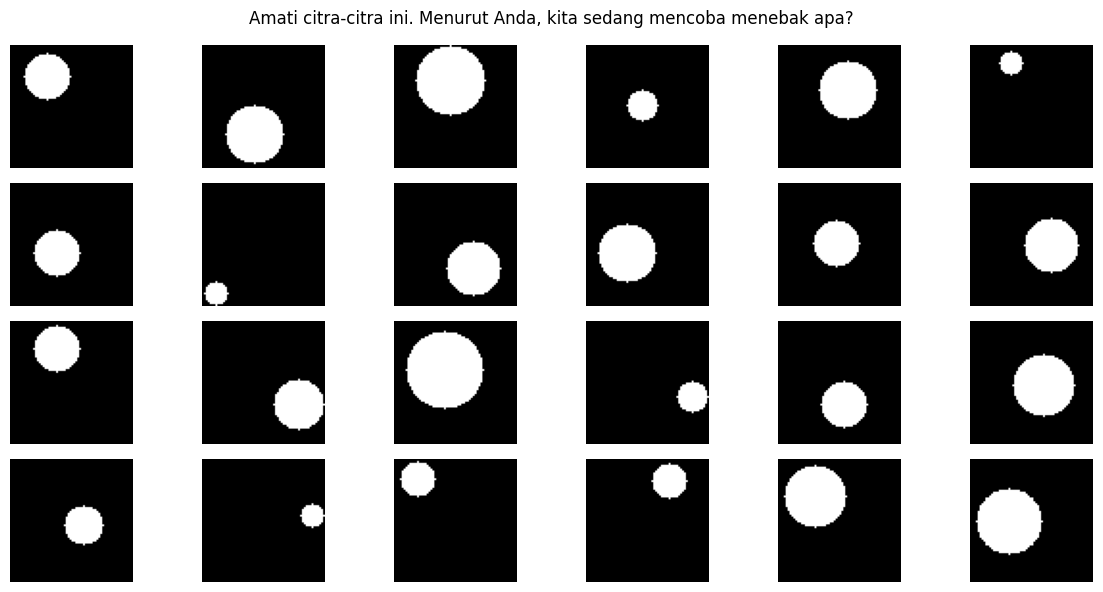

In [ ]:
# Buat 24 contoh untuk visualisasi
N_show = 24
samples = [make_sample() for _ in range(N_show)]
imgs = [s[0] for s in samples]
rads = [s[1] for s in samples]
centers = [s[2] for s in samples]

# Grid gambar tanpa label:
cols = 6
rows = N_show // cols
plt.figure(figsize=(12, 6))
for i in range(N_show):
  plt.subplot(rows, cols, i+1)
  plt.imshow(imgs[i].squeeze(), cmap='gray')
  plt.axis('off')
plt.suptitle("Amati citra-citra ini. Menurut Anda, kita sedang mencoba menebak apa?")
plt.tight_layout()
plt.show()

3)	Buka Jawaban — Target yang Ingin Diprediksi

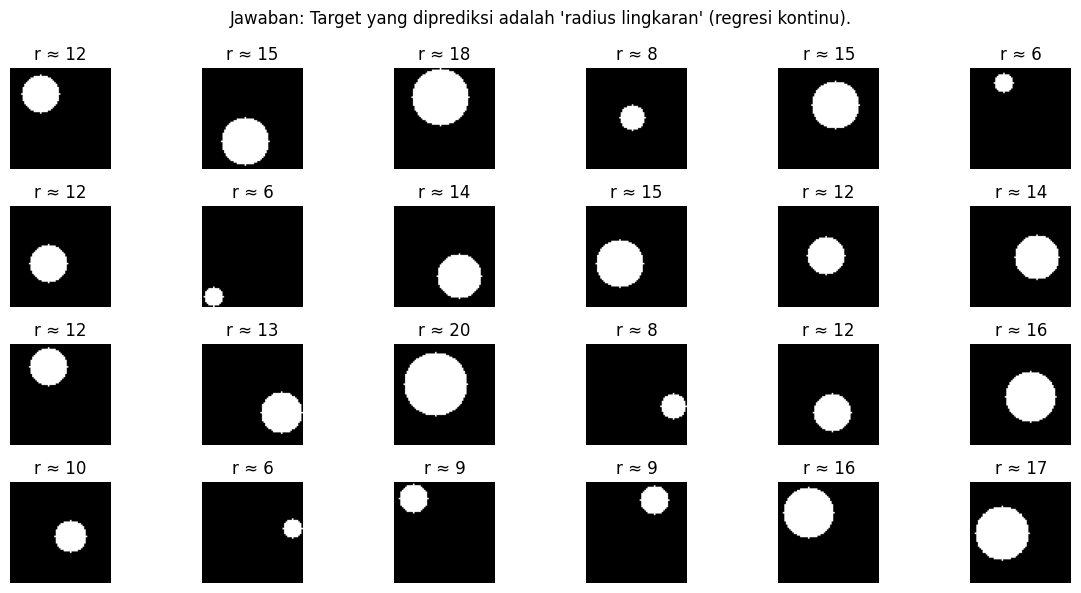

In [ ]:
# Tampilkan kembali, sekarang tampilkan radius (label) di judul tiap subplot
plt.figure(figsize=(12, 6))
for i in range(N_show):
  plt.subplot(rows, cols, i+1)
  plt.imshow(imgs[i].squeeze(), cmap='gray')
  plt.title(f"r ≈ {int(rads[i])}")
  plt.axis('off')
plt.suptitle("Jawaban: Target yang diprediksi adalah 'radius lingkaran' (regresi kontinu).")
plt.tight_layout()
plt.show()

4)	(Opsional) Latih CNN Kecil untuk Memprediksi Radius

In [ ]:
# Siapkan dataset lebih besar untuk training
N = 3000
X, y, C = zip(*[make_sample() for _ in range(N)])
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

# Model CNN sederhana
model = models.Sequential([
    layers.Input((64,64,3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1) # output regresi
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(Xtr, ytr, validation_data=(Xte, yte),
                    epochs=12, batch_size=64, verbose=0)

# Evaluasi
y_pred = model.predict(Xte).ravel()
mae = mean_absolute_error(yte, y_pred)
rmse = float(np.sqrt(np.mean((yte - y_pred)**2)))
r2 = r2_score(yte, y_pred)
print(f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
MAE=1.018 | RMSE=1.245 | R²=0.924


Plot history & True vs Predicted:

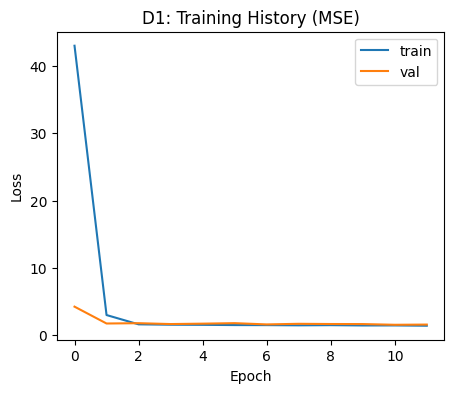

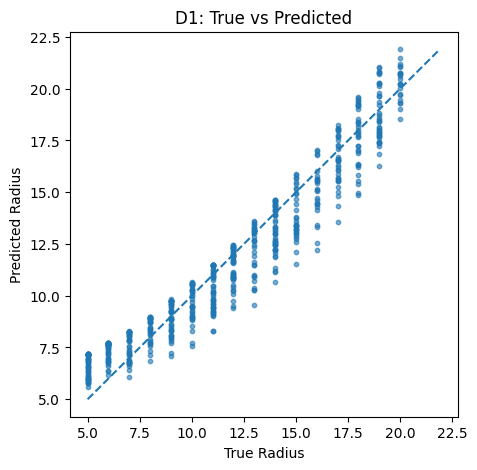

In [ ]:
# Plot loss
plt.figure(figsize=(5,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("D1: Training History (MSE)")
plt.xlabel("Epoch");
plt.ylabel("Loss");
plt.legend();
plt.show()

# Scatter True vs Pred
plt.figure(figsize=(5,5))
plt.scatter(yte, y_pred, s=10, alpha=0.6)
lims = [min(yte.min(), y_pred.min()), max(yte.max(), y_pred.max())]
plt.plot(lims, lims, '--')
plt.xlabel("True Radius");
plt.ylabel("Predicted Radius")
plt.title("D1: True vs Predicted")
plt.show()

5)	Tantangan Mini (Opsional untuk Mahasiswa)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Fungsi pembuatan sampel dengan rentang radius baru (8 - 28) dan multi-output [r, cx, cy]
def make_sample_multi():
    # Citra kosong ukuran 64x64
    img = np.zeros((64, 64, 3), dtype=np.float32)

    # Menentukan radius baru (mis. antara 8 sampai 28)
    r = np.random.randint(8, 29)

    # Menentukan titik pusat (cx, cy) secara acak dengan batas aman agar lingkaran tidak terpotong
    cx = np.random.randint(r + 2, 64 - r - 2)
    cy = np.random.randint(r + 2, 64 - r - 2)

    # Membuat koordinat grid untuk menggambar lingkaran
    y_idx, x_idx = np.ogrid[:64, :64]
    mask = (x_idx - cx)**2 + (y_idx - cy)**2 <= r**2

    # Beri warna putih pada area lingkaran
    img[mask] = [1.0, 1.0, 1.0]

    # --- OPSIONAL: Tambahan Noise atau Blur ---
    # A. Gaussian Noise
    noise = np.random.normal(0, 0.05, img.shape)
    img = np.clip(img + noise, 0.0, 1.0)

    # B. Blur (bisa diaktifkan jika ingin menguji efek blur)
    # img = tf.nn.avg_pool2d(img[np.newaxis, ...], ksize=3, strides=1, padding='SAME')[0].numpy()

    # Target multi-output: [radius, cx, cy]
    # Normalisasi koordinat pusat (opsional tapi disarankan, misal dibagi 64 agar skalanya mirip)
    y_target = np.array([r, cx, cy], dtype=np.float32)

    return img, y_target

# 2. Menyiapkan Dataset Lebih Besar (N = 3000)
N = 3000
X_list = []
y_list = []

for _ in range(N):
    img, target = make_sample_multi()
    X_list.append(img)
    y_list.append(target)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Arsitektur Model CNN untuk Multi-Output (3 neuron di output layer)
model = models.Sequential([
    layers.Input((64, 64, 3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3)  # Multi-output: memprediksi [r, cx, cy] sekaligus
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=15, batch_size=64, verbose=1)

# 4. Evaluasi Performa Multi-Output
y_pred = model.predict(Xte)

# Memisahkan hasil prediksi dan ground truth untuk masing-masing parameter [r, cx, cy]
labels = ['Radius (r)', 'Center X (cx)', 'Center Y (cy)']
for i in range(3):
    mae_i = mean_absolute_error(yte[:, i], y_pred[:, i])
    rmse_i = float(np.sqrt(np.mean((yte[:, i] - y_pred[:, i])**2)))
    r2_i = r2_score(yte[:, i], y_pred[:, i])
    print(f"--- Evaluasi {labels[i]} ---")
    print(f"MAE = {mae_i:.3f} | RMSE = {rmse_i:.3f} | R² = {r2_i:.3f}\n")

Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 512ms/step - loss: 365.9180 - mae: 14.6847 - val_loss: 85.8216 - val_mae: 6.3043
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 476ms/step - loss: 57.2352 - mae: 5.6545 - val_loss: 42.9267 - val_mae: 5.0963
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 468ms/step - loss: 42.3634 - mae: 4.7339 - val_loss: 38.8674 - val_mae: 4.2769
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 504ms/step - loss: 38.3656 - mae: 4.1489 - val_loss: 36.9436 - val_mae: 4.0422
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 469ms/step - loss: 36.9524 - mae: 4.0381 - val_loss: 34.1968 - val_mae: 3.9716
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 482ms/step - loss: 35.9351 - mae: 3.9743 - val_loss: 32.9812 - val_mae: 3.8664
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 467ms/step - loss: 34.9664 - mae: 3.9216 - val_loss: 33.8149 - val_mae: 3.9447
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 493ms/step - loss: 34.6010 - mae: 3.9101 - val_loss: 31.6644 - val_mae: 3.8085
Epoch 9/15
38/38 ━━━━━━━━━━━━━

Praktikum D2 – Menebak Umur Manusia dari Foto Wajah (UTKFace)

Langkah 1 — Membuat Akun Kaggle dan Mengunduh kaggle.json

In [ ]:
#Jalankan ini diawal notebook
from google.colab import files
files.upload() #pilih file kaggle.json dari komputer anda

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aisaretalestariti","key":"bc2ba08bf082269e8144a326f70a89df"}'}

In [ ]:
import os, shutil
if os.path.exists("kaggle.json"):
  os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
  shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
  os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
  !pip -q install kaggle
  print("✅ Kaggle API siap digunakan.")
else:
  print(" .ı kaggle.json belum ditemukan. Upload terlebih dahulu.")

✅ Kaggle API siap digunakan.


Langkah 3 — Mengunduh Dataset UTKFace dari Kaggle

In [ ]:
# Unduh dataset UTKFace (sekali saja)
!kaggle datasets download -d jangedoo/utkface-new -p /content -q
!unzip -q /content/utkface-new.zip -d /content/utk
print("✅ Dataset UTKFace berhasil diekstrak.")

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
✅ Dataset UTKFace berhasil diekstrak.


Langkah 4 — Menampilkan Contoh Gambar Dataset

Total gambar ditemukan: 23708


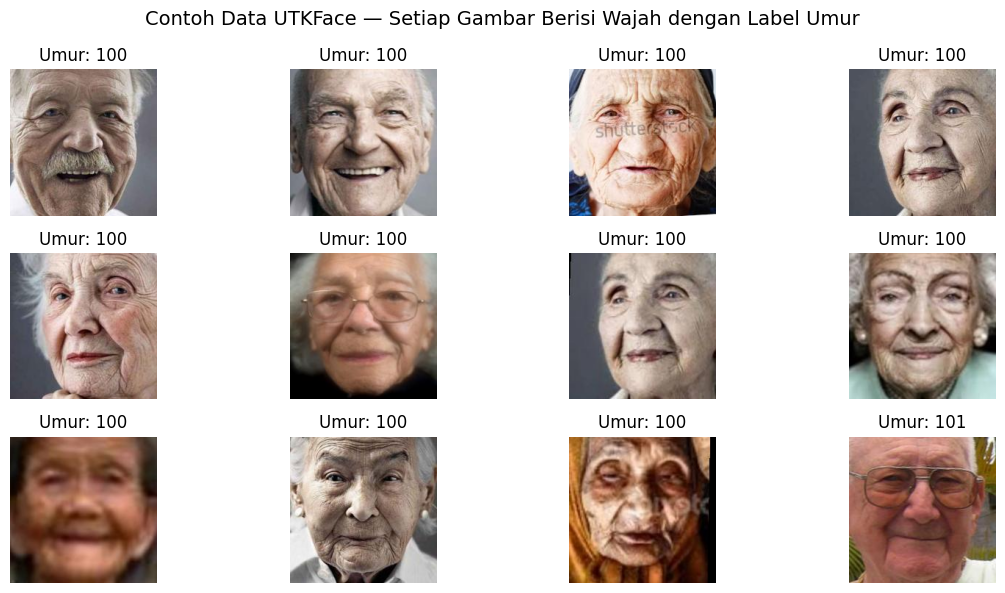

In [ ]:
import matplotlib.pyplot as plt
import os, glob
from PIL import Image

# Ambil 12 gambar acak dari dataset
files = glob.glob("/content/utk/UTKFace/*.jpg")
files = sorted(files)
print(f"Total gambar ditemukan: {len(files)}")

plt.figure(figsize=(12, 6))
for i, f in enumerate(files[:12]):
  # Ambil umur dari nama file
  age = int(os.path.basename(f).split("_")[0])
  img = Image.open(f)
  plt.subplot(3, 4, i + 1)
  plt.imshow(img)
  plt.title(f"Umur: {age}")
  plt.axis("off")
plt.suptitle("Contoh Data UTKFace — Setiap Gambar Berisi Wajah dengan Label Umur", fontsize=14)
plt.tight_layout()
plt.show()

Langkah 5 — Siapkan Dataset untuk Model

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

def parse_age_from_name(fp):
  return int(os.path.basename(fp).split('_')[0])

ages = np.array([parse_age_from_name(f) for f in files], dtype=np.float32)
train_files, test_files, y_train, y_test = train_test_split(
    files, ages, test_size=0.2, random_state=42
)

IMG_SIZE = 160
def load_img(fp, label):
  img = tf.io.read_file(fp)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
  return img / 255.0, label

train_ds = tf.data.Dataset.from_tensor_slices((train_files, y_train)).map(load_img).batch(64)
test_ds = tf.data.Dataset.from_tensor_slices((test_files, y_test)).map(load_img).batch(64)

print("✅ Dataset siap dilatih.")

✅ Dataset siap dilatih.


Langkah 6 — Membangun Model dengan Transfer Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Gunakan GPU jika tersedia
print("Hardware:", "GPU" if tf.config.list_physical_devices('GPU') else "CPU")

# Buat arsitektur model
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)
base_model.trainable = False # tahap awal: freeze backbone

# Tambahkan head regresi
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1)(x) # output tunggal: umur
model = tf.keras.Model(inputs, outputs)

# Kompilasi model
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='mse', metrics=['mae'])

model.summary()

Hardware: CPU
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Langkah 7 — Melatih Model (Tahap 1 – Frozen)

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 582s 2s/step - loss: 219.4374 - mae: 11.0491 - val_loss: 158.5278 - val_mae: 9.5582 - learning_rate: 0.0010
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 563s 2s/step - loss: 150.3212 - mae: 9.0975 - val_loss: 144.8987 - val_mae: 8.9936 - learning_rate: 0.0010
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 526s 2s/step - loss: 142.9167 - mae: 8.8647 - val_loss: 140.7764 - val_mae: 8.8031 - learning_rate: 0.0010
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 559s 2s/step - loss: 139.7623 - mae: 8.7367 - val_loss: 138.0082 - val_mae: 8.6520 - learning_rate: 0.0010
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 555s 2s/step - loss: 137.4699 - mae: 8.6589 - val_loss: 137.9543 - val_mae: 8.6998 - learning_rate: 0.0010
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - loss: 133.7122 - mae: 8.5213 - val_loss: 137.0467 - val_mae: 8.7022 - learning_rate: 0.0010
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 581s 2s/step - loss: 132.7565 - mae: 8.4809 - val_loss: 133.9516 - val_mae: 8

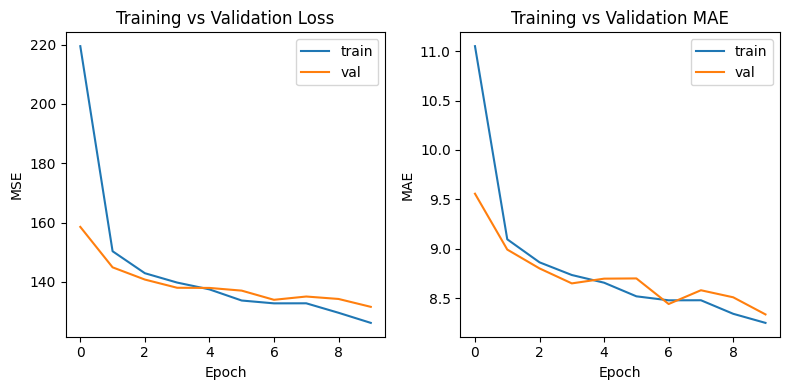

In [ ]:
# Callback untuk pelatihan yang lebih stabil
cb = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e-5, monitor='val_loss')
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=cb,
    verbose=1
)

# Visualisasi perubahan loss dan MAE selama pelatihan:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.tight_layout()
plt.show()

Langkah 8 — Fine-tuning Backbone (Tahap 2)

Epoch 1/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 800s 3s/step - loss: 144.3755 - mae: 8.8191 - val_loss: 140.3845 - val_mae: 8.6962 - learning_rate: 1.0000e-04
Epoch 2/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 861s 3s/step - loss: 72.4050 - mae: 6.3300 - val_loss: 134.2732 - val_mae: 8.8999 - learning_rate: 1.0000e-04
Epoch 3/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 754s 3s/step - loss: 46.7657 - mae: 5.1236 - val_loss: 107.9000 - val_mae: 7.6915 - learning_rate: 5.0000e-05
Epoch 4/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 853s 3s/step - loss: 36.0211 - mae: 4.5548 - val_loss: 101.1557 - val_mae: 7.3797 - learning_rate: 5.0000e-05
Epoch 5/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 820s 3s/step - loss: 29.7890 - mae: 4.1382 - val_loss: 95.9073 - val_mae: 7.0392 - learning_rate: 5.0000e-05


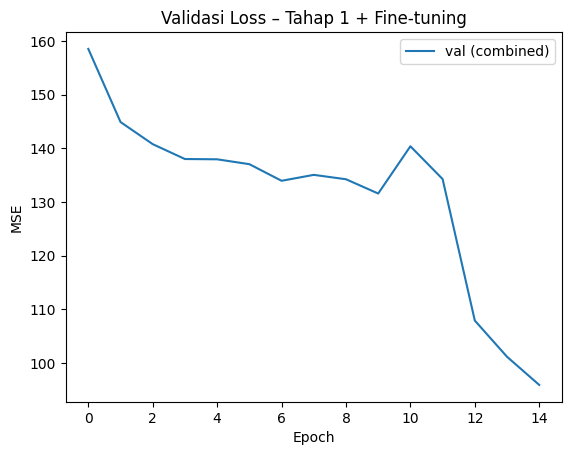

In [ ]:
# Aktifkan kembali sebagian layer terakhir untuk fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
  layer.trainable = False # beku sebagian besar layer

# Recompile dengan learning rate lebih kecil
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='mse', metrics=['mae'])

history_ft = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    callbacks=cb,
    verbose=1
)

# Visualisasi gabungan training dan fine-tuning:
plt.plot(history.history['val_loss'] + history_ft.history['val_loss'],
label='val (combined)')
plt.title("Validasi Loss – Tahap 1 + Fine-tuning")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.legend(); plt.show()

Langkah 9 — Evaluasi Akhir (MAE, RMSE, R²)

MAE = 7.04 tahun
RMSE = 9.79 tahun
R² = 0.758


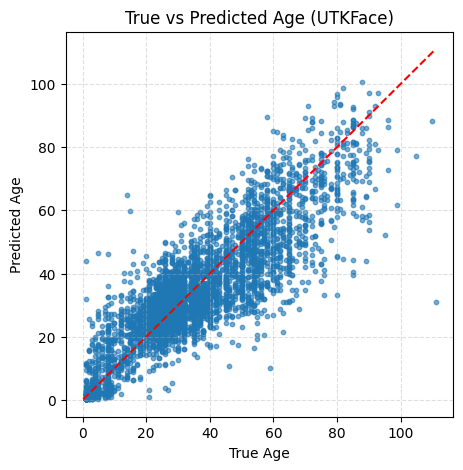

In [ ]:
from math import sqrt

y_true = np.concatenate([batch[1] for batch in test_ds])
y_pred = np.concatenate([model.predict(batch[0], verbose=0).ravel() for batch in test_ds])
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
r2 = r2_score(y_true, y_pred)

print(f"MAE = {mae:.2f} tahun")
print(f"RMSE = {rmse:.2f} tahun")
print(f"R² = {r2:.3f}")

#Plot "umur sebenarnya vs umur prediksi":
plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, s=10, alpha=0.6)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red')
plt.xlabel("True Age");
plt.ylabel("Predicted Age")
plt.title("True vs Predicted Age (UTKFace)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Langkah 10 — Melihat Contoh Prediksi Nyata

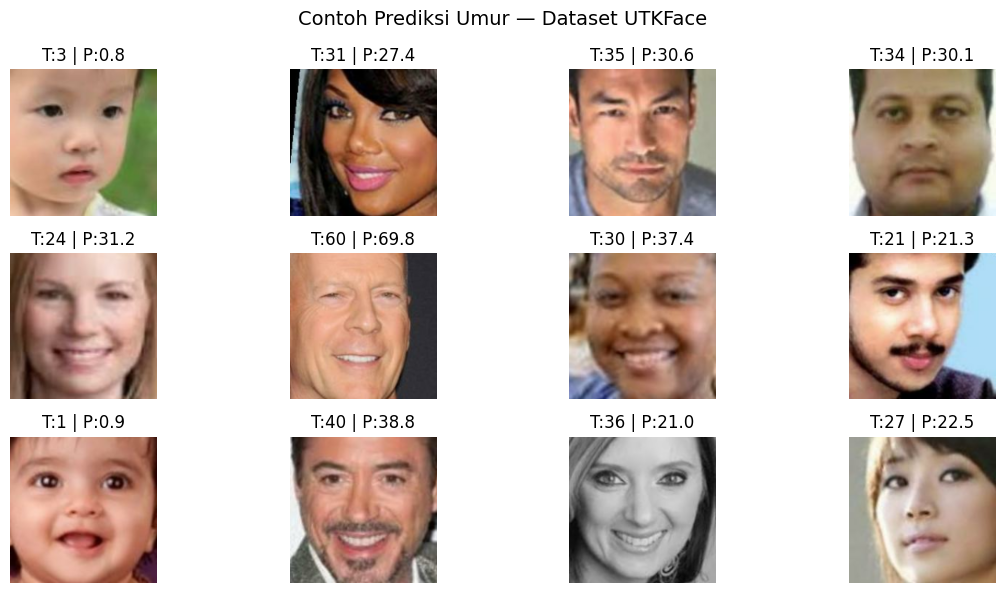

In [ ]:
import random
sample_paths = random.sample(test_files, 12)

plt.figure(figsize=(12,6))
for i, path in enumerate(sample_paths):
  img = tf.io.read_file(path)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))/255.0
  true_age = int(os.path.basename(path).split('_')[0])
  pred_age = model.predict(tf.expand_dims(img, 0), verbose=0).ravel()[0]
  plt.subplot(3,4,i+1)
  plt.imshow(img.numpy())
  plt.title(f"T:{true_age} | P:{pred_age:.1f}")
  plt.axis('off')
plt.suptitle("Contoh Prediksi Umur — Dataset UTKFace", fontsize=14)
plt.tight_layout()
plt.show()

Praktikum D3 — Menilai “Kepopuleran Hewan Peliharaan” dari Foto

In [ ]:
from google.colab import files
files.upload() # pilih kaggle.json dari komputer Anda
import os, shutil
if os.path.exists("kaggle.json"):
  os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
  shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
  os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
  !pip -q install kaggle
  print("✅ Kaggle API siap digunakan.")
else:
  print(" ı. kaggle.json belum ditemukan. Upload terlebih dahulu.")

Saving kaggle.json to kaggle (1).json
✅ Kaggle API siap digunakan.


Langkah 2 — Mengunduh dan Mengekstrak Dataset

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_273cf389f2a2e659026dc868e77bb3b2"

In [ ]:
!mkdir -p ~/.kaggle && echo KGAT_273cf389f2a2e659026dc868e77bb3b2 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
# 1. Update package kaggle ke versi terbaru
!pip install --upgrade kaggle

# 2. Setel token API
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_273cf389f2a2e659026dc868e77bb3b2"

# 3. Download dan ekstrak dataset
!kaggle competitions download -c petfinder-pawpularity-score -p /content
!unzip -o /content/petfinder-pawpularity-score.zip -d /content/paw
print("Dataset Pawpularity berhasil diekstrak.")

Streaming output truncated to the last 5000 lines.
  inflating: /content/paw/train/7e51d9305ec464c1f77cfee35ceb1b4f.jpg  
  inflating: /content/paw/train/7e56aa71d1e091e004703283323e8e7f.jpg  
  inflating: /content/paw/train/7e5d1650d5cda4d68f2ee8ce17c29b25.jpg  
  inflating: /content/paw/train/7e601feb12f2fb03c2d342e54cd47b1e.jpg  
  inflating: /content/paw/train/7e6ca633d2a751af58e1cc220ca519b3.jpg  
  inflating: /content/paw/train/7e717923c22053e51861a24aae701fb0.jpg  
  inflating: /content/paw/train/7e761f47cc1e3038a431f9f196234ab9.jpg  
  inflating: /content/paw/train/7e7921ed945c3c863882340360c9157d.jpg  
  inflating: /content/paw/train/7e8763e28a01c059b7a8d119c5ae0dc0.jpg  
  inflating: /content/paw/train/7e93691bef9bc381590cf004358ee11a.jpg  
  inflating: /content/paw/train/7e947e83394b6d74f1ec4f5b596bed6a.jpg  
  inflating: /content/paw/train/7e9d46bd87849a49ada5f2c336c9d929.jpg  
  inflating: /content/paw/train/7e9df6c36fd06411ce717d0ce761af35.jpg  
  inflating: /content/paw/

Langkah 3 — Melihat Contoh Data

                                 Id  Subject Focus  Eyes  Face  Near  Action  \
0  0007de18844b0dbbb5e1f607da0606e0              0     1     1     1       0   
1  0009c66b9439883ba2750fb825e1d7db              0     1     1     0       0   
2  0013fd999caf9a3efe1352ca1b0d937e              0     1     1     1       0   
3  0018df346ac9c1d8413cfcc888ca8246              0     1     1     1       0   
4  001dc955e10590d3ca4673f034feeef2              0     0     0     1       0   

   Accessory  Group  Collage  Human  Occlusion  Info  Blur  Pawpularity  \
0          0      1        0      0          0     0     0           63   
1          0      0        0      0          0     0     0           42   
2          0      0        0      1          1     0     0           28   
3          0      0        0      0          0     0     0           15   
4          0      1        0      0          0     0     0           72   

                                                path  
0  /content/p

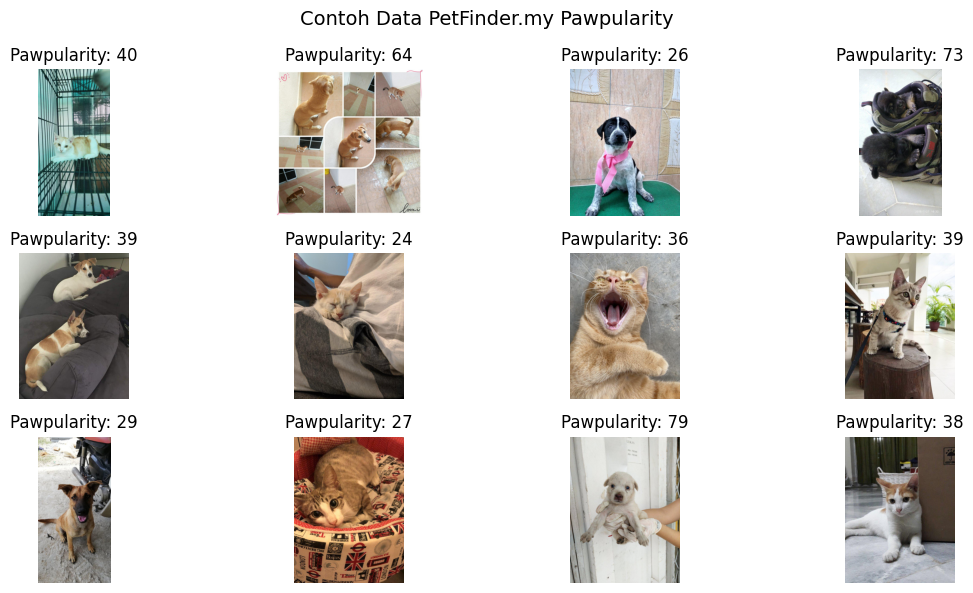

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

# Muat CSV
df = pd.read_csv('/content/paw/train.csv')
df['path'] = df['Id'].apply(lambda x: f"/content/paw/train/{x}.jpg")
print(df.head())

# Tampilkan 12 contoh gambar
plt.figure(figsize=(12, 6))
for i, row in enumerate(df.sample(12, random_state=42).itertuples()):
  img = Image.open(row.path)
  plt.subplot(3, 4, i + 1)
  plt.imshow(img)
  plt.title(f"Pawpularity: {row.Pawpularity}")
  plt.axis('off')
plt.suptitle("Contoh Data PetFinder.my Pawpularity", fontsize=14)
plt.tight_layout()
plt.show()

Langkah 4 — Persiapan Dataset

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

IMG_SIZE = 224
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

def load_image(path, label):
  img = tf.io.read_file(path)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
  img = tf.cast(img, tf.float32) / 255.0
  return img, tf.cast(label, tf.float32)

train_ds = tf.data.Dataset.from_tensor_slices((train_df['path'], train_df['Pawpularity']))\
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)\
    .shuffle(4096).batch(64).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_df['path'], val_df['Pawpularity']))\
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)\
    .batch(64).prefetch(tf.data.AUTOTUNE)

print(f"Dataset siap digunakan — {len(train_df)} untuk training, {len(val_df)} untuk validasi.")

Dataset siap digunakan — 7929 untuk training, 1983 untuk validasi.


Langkah 4 — Membangun Model (EfficientNetB0)

In [ ]:
from tensorflow.keras import layers, models

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)
base.trainable = False # freeze sementara

inputs = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs * 255.0)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(1)(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Langkah 5 — Melatih Model

In [10]:
cb = [
    tf.keras.callbacks.EarlyStopping(patience=3,
restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)
]

history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=cb, verbose=1)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1001s 8s/step - loss: 606.0946 - mae: 18.0805 - val_loss: 479.3765 - val_mae: 16.0108 - learning_rate: 0.0010
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 876s 7s/step - loss: 424.4214 - mae: 15.1970 - val_loss: 428.5558 - val_mae: 15.4185 - learning_rate: 0.0010
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 852s 7s/step - loss: 390.7072 - mae: 14.6647 - val_loss: 402.8172 - val_mae: 14.7706 - learning_rate: 0.0010
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 797s 6s/step - loss: 374.2198 - mae: 14.3432 - val_loss: 386.8970 - val_mae: 14.4651 - learning_rate: 0.0010
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 803s 6s/step - loss: 362.3441 - mae: 14.1127 - val_loss: 383.3379 - val_mae: 14.6686 - learning_rate: 0.0010
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 892s 7s/step - loss: 355.7012 - mae: 13.9959 - val_loss: 372.3349 - val_mae: 14.2034 - learning_rate: 0.0010
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 786s 6s/step - loss: 342.8559 - mae: 13.7303 - val_loss: 365.9840

Langkah 6 — Melihat Proses Belajar

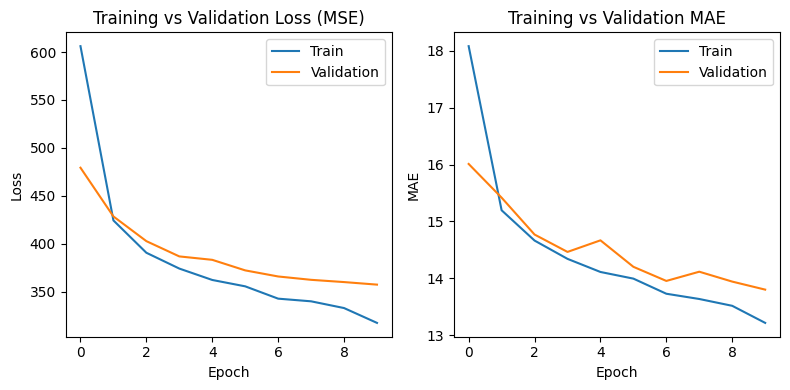

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Training vs Validation Loss (MSE)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train')
plt.plot(history.history['val_mae'], label='Validation')
plt.title("Training vs Validation MAE")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.legend()
plt.tight_layout()
plt.show()

Langkah 7 — Evaluasi Model

MAE = 13.80
RMSE = 18.91
R²	= 0.191


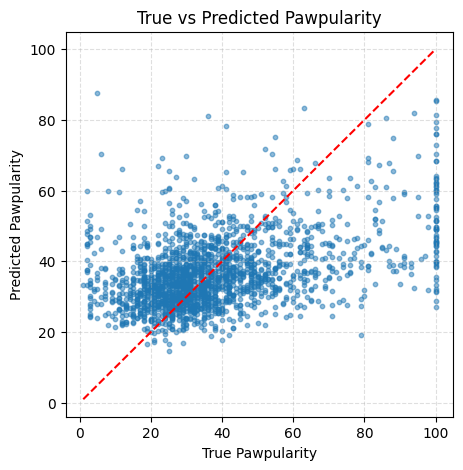

In [12]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from math import sqrt

y_true = val_df['Pawpularity'].values.astype(np.float32)
y_pred = np.concatenate([model.predict(batch[0], verbose=0).ravel() for batch in val_ds])

mae = mean_absolute_error(y_true, y_pred)
rmse = sqrt(np.mean((y_true - y_pred)**2))
r2 = r2_score(y_true, y_pred)

print(f"MAE = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²	= {r2:.3f}")

# Plot hasil prediksi vs nilai sebenarnya:
plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, s=10, alpha=0.5)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red')
plt.xlabel("True Pawpularity")
plt.ylabel("Predicted Pawpularity")
plt.title("True vs Predicted Pawpularity")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Langkah 8 — Melihat Contoh Prediksi

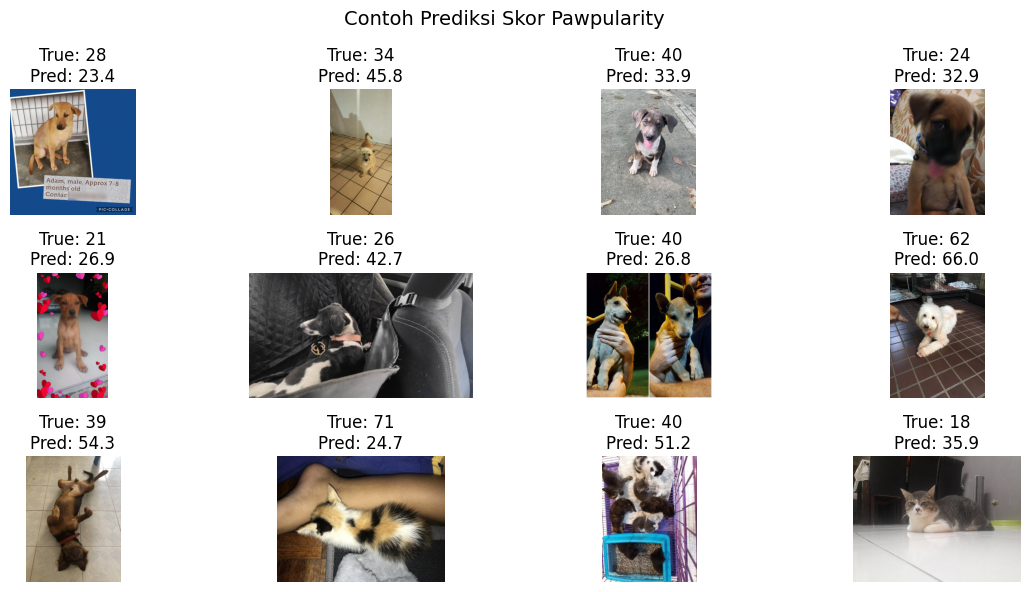

In [14]:
import random
from PIL import Image

sample_rows = val_df.sample(12, random_state=1)

plt.figure(figsize=(12,6))
for i, row in enumerate(sample_rows.itertuples()):
  img = Image.open(row.path)
  pred = model.predict(tf.expand_dims(load_image(row.path, row.Pawpularity)[0], 0), verbose=0).ravel()[0]
  plt.subplot(3,4,i+1)
  plt.imshow(img)
  plt.title(f"True: {row.Pawpularity}\nPred: {pred:.1f}")
  plt.axis('off')
plt.suptitle("Contoh Prediksi Skor Pawpularity", fontsize=14)
plt.tight_layout()
plt.show()

Tantangan Mini

In [15]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3, ResNet50
import cv2
import matplotlib.pyplot as plt

# ==========================================
# 1. PERSIAPAN DATA & FITUR NON-VISUAL (Brightness)
# ==========================================
# Asumsi: Anda memiliki DataFrame 'df' dengan kolom ['path', 'Pawpularity', 'Species']
# (Species: 0 untuk Kucing, 1 untuk Anjing)

def calculate_brightness(image_path):
    """Menghitung rata-rata kecerahan (brightness) dari sebuah gambar."""
    try:
        img = cv2.imread(image_path)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        return hsv[..., 2].mean() / 255.0 # Normalisasi 0-1
    except:
        return 0.5 # Nilai tengah jika gambar gagal dimuat

# Tambahkan fitur non-visual ke dalam dataframe
# df['brightness'] = df['path'].apply(calculate_brightness)
print("Fitur non-visual (brightness) berhasil ditambahkan.")

# ==========================================
# 2. DATA PIPELINE & AUGMENTASI
# ==========================================
IMG_SIZE = 300 # Gunakan 300 untuk EfficientNetB3, 224 untuk ResNet50
BATCH_SIZE = 32

# Definisi Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

def process_data(image_path, brightness, pawpularity):
    """Memuat dan meresize gambar, serta menyatukan input."""
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return (image, brightness), pawpularity

# Contoh pembuatan tf.data.Dataset (Gunakan df_train dan df_val Anda)
# train_ds = tf.data.Dataset.from_tensor_slices((df_train['path'], df_train['brightness'], df_train['Pawpularity']))
# train_ds = train_ds.map(process_data).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ==========================================
# 3. PEMBUATAN MODEL MULTI-INPUT (EfficientNetB3 / ResNet50)
# ==========================================
def build_model(use_efficientnet=True):
    # A. Input Gambar
    image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
    x = data_augmentation(image_input) # Terapkan augmentasi

    # Pilih Backbone (Tantangan 2)
    if use_efficientnet:
        # EfficientNetB3 sudah memiliki preprocessing internal bawaan Keras
        backbone = EfficientNetB3(include_top=False, weights='imagenet', pooling='avg')
    else:
        # Gunakan ResNet50 sebagai perbandingan
        x = tf.keras.applications.resnet50.preprocess_input(x)
        backbone = ResNet50(include_top=False, weights='imagenet', pooling='avg')

    backbone.trainable = False # Freeze weights awal
    img_features = backbone(x)

    # B. Input Non-Visual (Brightness)
    tabular_input = layers.Input(shape=(1,), name="tabular_input")
    tab_features = layers.Dense(16, activation="relu")(tabular_input)

    # C. Gabungkan Fitur (Visual + Non-Visual)
    concat = layers.Concatenate()([img_features, tab_features])

    # D. Head Regresi
    x = layers.Dense(128, activation="relu")(concat)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, name="pawpularity_output")(x) # Prediksi skor numerik

    model = models.Model(inputs=[image_input, tabular_input], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])
    return model

model = build_model(use_efficientnet=True)
model.summary()

# Latih Model
# history = model.fit(train_ds, validation_data=val_ds, epochs=5)

# ==========================================
# 4. EKSPERIMEN BIAS: ANJING VS KUCING
# ==========================================
def evaluate_bias(model, val_df):
    """
    Menganalisis apakah model memiliki bias prediksi terhadap spesies tertentu.
    Ini membantu kita memahami apakah "otak model" menilai secara adil.
    """
    print("\n--- Evaluasi Bias Spesies ---")

    # Prediksi seluruh data validasi
    # val_images, val_brightness = load_validation_data_as_numpy(val_df)
    # predictions = model.predict([val_images, val_brightness]).ravel()
    # val_df['Prediction'] = predictions

    # Asumsi val_df sudah berisi kolom 'Pawpularity' (True) dan 'Prediction'
    # Serta kolom 'Species' (Kucing/Anjing)

    # Filter dataset
    dogs_df = val_df[val_df['Species'] == 'Dog']
    cats_df = val_df[val_df['Species'] == 'Cat']

    # Hitung metrik Error (RMSE) untuk masing-masing
    if not dogs_df.empty and not cats_df.empty:
        rmse_dogs = np.sqrt(((dogs_df['Prediction'] - dogs_df['Pawpularity']) ** 2).mean())
        rmse_cats = np.sqrt(((cats_df['Prediction'] - cats_df['Pawpularity']) ** 2).mean())

        print(f"RMSE Anjing : {rmse_dogs:.2f}")
        print(f"RMSE Kucing : {rmse_cats:.2f}")

        if abs(rmse_dogs - rmse_cats) > 5.0: # Threshold asumsi
            print("Kesimpulan: Terdapat indikasi bias. Model lebih kesulitan memprediksi skor salah satu spesies.")
        else:
            print("Kesimpulan: Model cukup seimbang (tidak bias) antara anjing dan kucing.")
    else:
        print("Data spesies tidak lengkap untuk evaluasi.")

# Panggil fungsi evaluasi setelah training selesai
# evaluate_bias(model, df_val)

Fitur non-visual (brightness) berhasil ditambahkan.
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 300, 300,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb3      │ (None, 1536)      │ 10,783,535 │ data_augmentatio… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │         32 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1552)      │          0 │ efficientnetb3[0… │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │    198,784 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pawpularity_output  │ (None, 1)         │        129 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,982,480 (41.89 MB)

 Trainable params: 198,945 (777.13 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

PENUGASAN

Unggah foto pribadi Anda untuk prediksi usia:


Saving WhatsApp Image 2026-01-04 at 10.31.31 AM.jpeg to WhatsApp Image 2026-01-04 at 10.31.31 AM.jpeg
Peringatan: Model belum dimasukkan. Ini adalah nilai dummy.


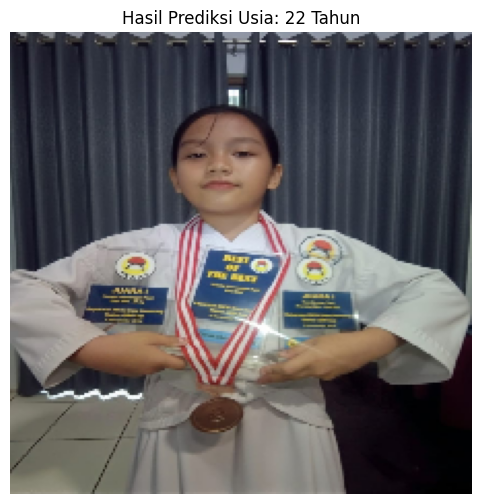

In [16]:
# ==========================================
# PENUGASAN 3: PREDIKSI USIA FOTO PRIBADI
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from google.colab import files

print("Unggah foto pribadi Anda untuk prediksi usia:")
uploaded = files.upload()
# Mengambil nama file gambar yang baru saja diunggah
file_name = list(uploaded.keys())[0]

# --- PENTING: Load Model Anda ---
# Pastikan Anda sudah melatih model usia atau memuatnya dari file .h5
# Contoh:
# model_usia = tf.keras.models.load_model('path_ke_model_usia_kalian.h5')

def prediksi_usia(img_path, model=None, target_size=(224, 224)):
    # 1. Muat dan preprocessing gambar
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0 # Sesuaikan normalisasi dengan yang diajarkan dosen

    # 2. Lakukan Prediksi
    if model is not None:
        prediksi = model.predict(img_array)[0][0]
    else:
        # Ini adalah nilai dummy (sementara) jika model belum di-load
        prediksi = 22.5
        print("Peringatan: Model belum dimasukkan. Ini adalah nilai dummy.")

    # 3. Tampilkan Hasil
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Hasil Prediksi Usia: {int(prediksi)} Tahun")
    plt.axis('off')
    plt.show()

# Jalankan fungsi
# Ubah 'None' menjadi 'model_usia' milik Anda jika sudah ada
prediksi_usia(file_name, model=None)

Unggah foto hewan peliharaan (atau foto pribadi) Anda untuk uji Pawpularity:


Saving 1.jpeg to 1.jpeg
Peringatan: Model belum dimasukkan. Ini adalah nilai dummy.


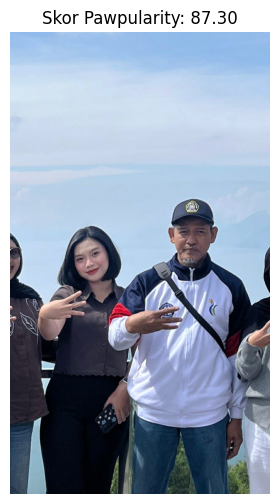

In [17]:
# ==========================================
# PENUGASAN 4: UJI MODEL PAWPULARITY
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from google.colab import files

print("Unggah foto hewan peliharaan (atau foto pribadi) Anda untuk uji Pawpularity:")
uploaded_paw = files.upload()
file_paw_name = list(uploaded_paw.keys())[0]

# Fungsi ekstraksi fitur non-visual (opsional jika model Anda menggunakan ini)
def hitung_brightness(image_path):
    try:
        img = cv2.imread(image_path)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        return hsv[..., 2].mean() / 255.0
    except:
        return 0.5

# --- PENTING: Load Model Anda ---
# Contoh:
# model_pawpularity = tf.keras.models.load_model('path_ke_model_pawpularity.h5')

def prediksi_pawpularity(img_path, model=None, target_size=(300, 300)):
    # 1. Preprocessing Gambar (sesuai format tf.data di tugas sebelumnya)
    img_raw = tf.io.read_file(img_path)
    img_tensor = tf.image.decode_jpeg(img_raw, channels=3)
    img_resized = tf.image.resize(img_tensor, target_size)
    img_input = tf.expand_dims(img_resized, 0) # Tambahkan dimensi batch

    # 2. Hitung Brightness (Untuk model Multi-Input)
    brightness_val = hitung_brightness(img_path)
    brightness_input = tf.constant([[brightness_val]])

    # 3. Prediksi
    if model is not None:
        # Gunakan baris di bawah ini JIKA model multi-input (Gambar + Brightness)
        # skor = model.predict([img_input, brightness_input])[0][0]

        # Gunakan baris di bawah ini JIKA model single-input (Hanya Gambar)
        skor = model.predict(img_input)[0][0]
    else:
        # Nilai dummy (sementara) jika model belum di-load
        skor = 87.3
        print("Peringatan: Model belum dimasukkan. Ini adalah nilai dummy.")

    # 4. Tampilkan Gambar beserta Skornya untuk laporan
    plt.figure(figsize=(6, 6))
    plt.imshow(tf.cast(img_tensor, tf.uint8)) # Menampilkan gambar resolusi asli
    plt.title(f"Skor Pawpularity: {skor:.2f}")
    plt.axis('off')
    plt.show()

# Jalankan fungsi
# Ubah 'None' menjadi nama variabel model Pawpularity Anda (misal: model_pawpularity)
prediksi_pawpularity(file_paw_name, model=None, target_size=(300, 300))